# Gold nanoparticle reconstruction in quantem 

Notebook from Georgios Varnavides and Stephanie Ribet

Data collected by Stephanie Ribet, TEAM I, Jan 2025

In [1]:
import numpy as np
import quantem as em
import matplotlib.pyplot as plt

from quantem.diffractive_imaging.direct_ptychography import OptimizationParameter

print(em.__version__)

/Users/gvarnavides/Documents/papers/mrs-bulletin-phase-retrieval-abcs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.1.8


## Load Calibrated Data

In [2]:
# Data can be downloaded from
dc = em.io.load("data/gold_arina_calibrated.zip")
dc

Dataset(shape=(154, 154, 192, 192), dtype=uint16, name='4D-STEM dataset')
  sampling: [1.328125  1.328125  0.4547657 0.4547657]
  units: ['A', 'A', 'mrad', 'mrad']
  signal units: 'arb. units'

In [3]:
PROBE_SEMIANGLE = 21.9
ENERGY = 300e3

## Direct Ptychography Preprocessing

In [4]:
direct_ptycho = em.diffractive_imaging.DirectPtychography.from_dataset4d(
    dc,
    energy=ENERGY,
    semiangle_cutoff=PROBE_SEMIANGLE,
    aberration_coefs={},
    device="cpu",
    rotation_angle=np.deg2rad(-169), 
    max_batch_size=128
)

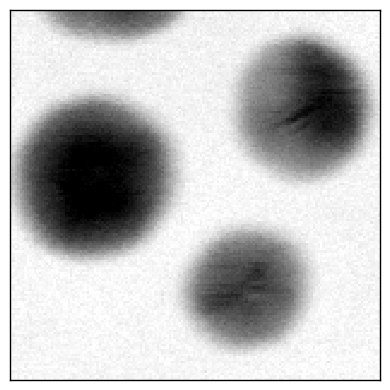

In [5]:
bf_obj = direct_ptycho.vbf_stack.sum(0).numpy()
em.visualization.show_2d(bf_obj);

## Direct Ptychography Optimization

In [6]:
direct_ptycho.optimize_hyperparameters(
    aberration_coefs={
        "C10":OptimizationParameter(-400,400),
        "C12":OptimizationParameter(0, 100),
        "phi12":OptimizationParameter(-np.pi/2, np.pi/2)
    },
    deconvolution_kernel='parallax',
    n_trials=150,
    max_batch_size=128,
)

Best trial: 126. Best value: 1.04895e-09: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [03:45<00:00,  1.50s/it]


Optimized state:

 HyperparameterState(
  initial_rotation_angle=np.float64(-2.949606435870417),
  optimized_aberrations={'C10': -355.6003071979114, 'C12': 74.85647460566031, 'phi12': 0.0669025131440751},
)


In [12]:
par_obj = direct_ptycho.reconstruct(
    deconvolution_kernel='parallax', 
    max_batch_size=64,
    upsampling_factor=3,
    verbose=False,
).obj

ssb_obj = direct_ptycho.reconstruct(
    deconvolution_kernel='ssb', 
    max_batch_size=64,
    upsampling_factor=3,
    verbose=False,
).obj

icom_obj = direct_ptycho.reconstruct(
    deconvolution_kernel='icom', 
    max_batch_size=64,
    verbose=False,
).obj

In [44]:
from dataclasses import replace

def fft(ar): 
    n0 = ar.shape
    w0 = np.hanning(n0[1]) * np.hanning(n0[0])[:, None]
    ar_fft = np.abs(np.fft.fftshift(np.fft.fft2(w0 * ar.copy())))
    return ar_fft

norm = em.visualization.NormalizationConfig(
    upper_quantile=0.995,
    lower_quantile = 0
)

crop = 20
pad = np.abs(par_obj.shape[0] - icom_obj.shape[0] )//2

scalebar_real = em.visualization.ScalebarConfig(
    sampling=dc.sampling[0]/10,
    units='nm',
    length=5,
)

scalebar_real_up = em.visualization.ScalebarConfig(
    sampling=dc.sampling[0]/10/3,
    units='nm',
    length=5,
)

scalebar_reciprocal = em.visualization.ScalebarConfig(
    sampling=np.fft.fftfreq(ssb_obj.shape[0],dc.sampling[0]/3)[1],
    units=r'$\AA^{-1}$',
    length=1,
    pad_px=0.5
)

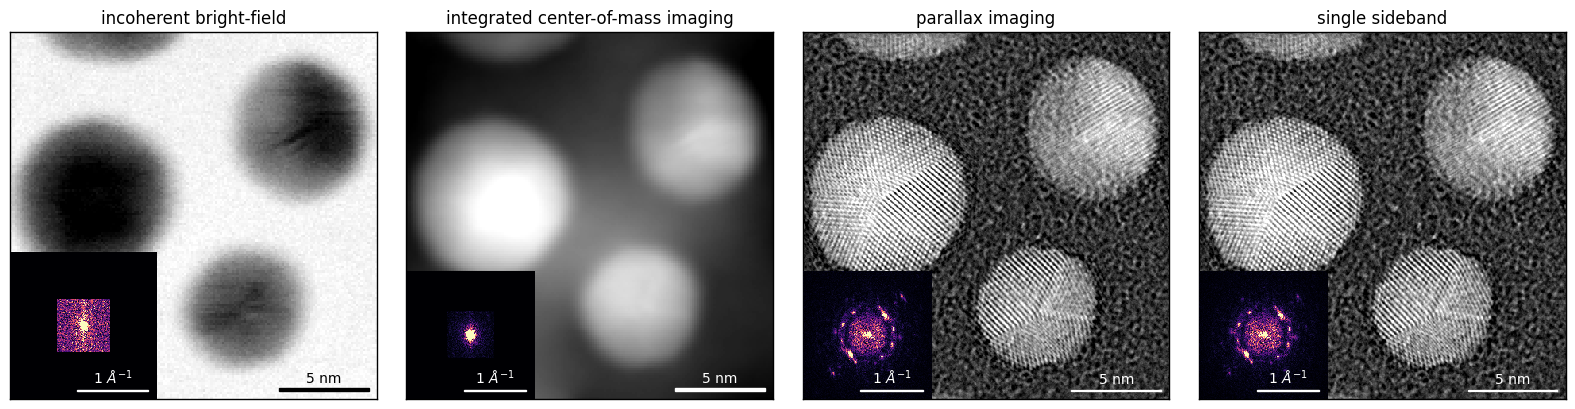

In [48]:
fig, ax = em.visualization.show_2d(
    [
        bf_obj,
        icom_obj,
        par_obj,
        ssb_obj,
    ],
    cmap=["gray"],
    title=["incoherent bright-field","integrated center-of-mass imaging","parallax imaging","single sideband"],
    scalebar=[
        replace(scalebar_real,color='black'),
        scalebar_real,
        scalebar_real_up,
        scalebar_real_up
    ],
    axsize=(4,4),
    returnfig = True,
);

ax_inset = ax[0].inset_axes([0, 0, 0.4, 0.4])
ax_inset.axis('off')
em.visualization.show_2d(
    np.pad(fft(bf_obj),((pad, pad),(pad, pad)))[crop:-crop,crop:-crop],
    figax = (fig, ax_inset),
    norm = norm,
    scalebar=scalebar_reciprocal,
    cmap = "magma"
);

ax_inset = ax[1].inset_axes([0, 0, 0.35, 0.35])
ax_inset.axis('off')
em.visualization.show_2d(
    np.pad(fft(icom_obj),((pad, pad),(pad, pad)))[crop:-crop,crop:-crop],
    figax = (fig, ax_inset),
    norm = norm,
    scalebar=scalebar_reciprocal,
    cmap = "magma"
);

ax_inset = ax[2].inset_axes([0, 0, 0.35, 0.35])
ax_inset.axis('off')
em.visualization.show_2d(
    fft(par_obj)[crop:-crop,crop:-crop],
    figax = (fig, ax_inset),
    norm = norm,
    scalebar=scalebar_reciprocal,
    cmap = "magma"
);

ax_inset = ax[3].inset_axes([0, 0, 0.35, 0.35])
ax_inset.axis('off')
em.visualization.show_2d(
    fft(ssb_obj)[crop:-crop,crop:-crop],
    figax = (fig, ax_inset),
    norm = norm,
    scalebar=scalebar_reciprocal,
    cmap = "magma"
);

plt.savefig('gold_inset.pdf', bbox_inches = "tight")

In [50]:
parallax_obj_no_upsample = direct_ptycho.reconstruct(
    deconvolution_kernel='parallax',
    max_batch_size=64,
).obj

Reconstructing with:

 HyperparameterState(
  current_aberrations={'C10': -355.6003071979114, 'C12': 74.85647460566031, 'phi12': 0.0669025131440751},
  current_rotation_angle=np.float64(-2.949606435870417),
)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7211/7211 [00:01<00:00, 6493.38it/s]


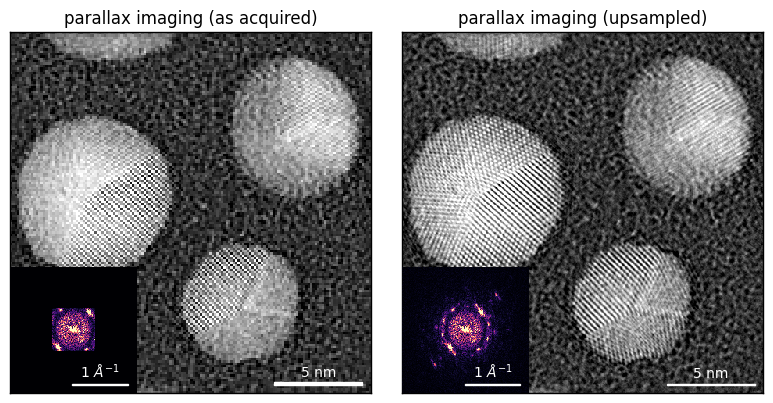

In [53]:
fig, ax = em.visualization.show_2d(
    [

        parallax_obj_no_upsample,
        par_obj,
    ],
    cmap=["gray"],
    title=["parallax imaging (as acquired)", "parallax imaging (upsampled)"],
    axsize=(4,4),
    returnfig = True,
    scalebar=[scalebar_real,scalebar_real_up],
)

ax_inset = ax[0].inset_axes([0, 0, 0.35, 0.35])
ax_inset.axis('off')
em.visualization.show_2d(
    np.pad(fft(parallax_obj_no_upsample),((pad, pad),(pad, pad))),
    figax = (fig, ax_inset),
    norm = norm,
    scalebar=scalebar_reciprocal,
    cmap = "magma"
);

ax_inset = ax[1].inset_axes([0, 0, 0.35, 0.35])
ax_inset.axis('off')
em.visualization.show_2d(
    fft(par_obj),
    figax = (fig, ax_inset),
    norm = norm,
    scalebar=scalebar_reciprocal,
    cmap = "magma"
);

plt.savefig('gold_upsample.pdf', bbox_inches = "tight")